In [1]:
import sqlite3
import os

db_path = os.path.join('..', 'data', 'recommender.db')
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS users (
    user_id INTEGER PRIMARY KEY,
    age INTEGER,
    language TEXT,
    location TEXT,
    signup_date TEXT
)
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS videos (
    video_id INTEGER PRIMARY KEY,
    category TEXT,
    language TEXT,
    duration_sec INTEGER,
    tags TEXT,
    upload_date TEXT
)
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS interactions (
    interaction_id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER,
    video_id INTEGER,
    watch_time_sec INTEGER,
    completion_rate REAL,
    liked INTEGER,
    timestamp TEXT,
    FOREIGN KEY (user_id) REFERENCES users(user_id),
    FOREIGN KEY (video_id) REFERENCES videos(video_id)
)
''')

conn.commit()
print("Tables created successfully at:", os.path.abspath(db_path))

Tables created successfully at: /Users/J/Documents/video-recommender/data/recommender.db


In [2]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('users',), ('videos',), ('interactions',), ('sqlite_sequence',)]


In [3]:
users = [
    (1, 22, 'English', 'Toronto', '2024-01-15'),
    (2, 28, 'Hindi', 'Mumbai', '2024-02-10'),
    (3, 35, 'Spanish', 'Madrid', '2024-01-20'),
    (4, 19, 'English', 'Vancouver', '2024-03-05'),
    (5, 41, 'Hindi', 'Toronto', '2024-02-28'),
]

cursor.executemany('''
INSERT OR REPLACE INTO users (user_id, age, language, location, signup_date)
VALUES (?, ?, ?, ?, ?)
''', users)

conn.commit()
print(f"Inserted {len(users)} users")

Inserted 5 users


In [4]:
videos = [
    (1, 'Comedy', 'English', 45, 'funny,skit', '2024-05-01'),
    (2, 'Comedy', 'English', 60, 'standup,funny', '2024-05-03'),
    (3, 'Sports', 'English', 120, 'football,highlights', '2024-04-20'),
    (4, 'Sports', 'Hindi', 90, 'cricket,highlights', '2024-04-22'),
    (5, 'Cooking', 'English', 180, 'recipe,quick', '2024-05-10'),
    (6, 'Cooking', 'Hindi', 150, 'recipe,traditional', '2024-05-11'),
    (7, 'Tech', 'English', 300, 'review,gadget', '2024-05-15'),
    (8, 'Tech', 'Spanish', 200, 'tutorial,coding', '2024-05-16'),
    (9, 'Music', 'Spanish', 210, 'song,live', '2024-05-18'),
    (10, 'Music', 'English', 180, 'song,cover', '2024-05-19'),
    (11, 'Gaming', 'English', 600, 'gameplay,funny', '2024-05-20'),
    (12, 'Gaming', 'Hindi', 450, 'gameplay,tutorial', '2024-05-21'),
    (13, 'Comedy', 'Spanish', 50, 'skit,funny', '2024-05-22'),
    (14, 'Sports', 'Spanish', 100, 'football,live', '2024-05-23'),
    (15, 'Music', 'Hindi', 195, 'song,live', '2024-05-24'),
]

cursor.executemany('''
INSERT OR REPLACE INTO videos (video_id, category, language, duration_sec, tags, upload_date)
VALUES (?, ?, ?, ?, ?, ?)
''', videos)

conn.commit()
print(f"Inserted {len(videos)} videos")

Inserted 15 videos


In [5]:
import pandas as pd

users_df = pd.read_sql_query("SELECT * FROM users", conn)
videos_df = pd.read_sql_query("SELECT * FROM videos", conn)

print(users_df)
print(videos_df)

   user_id  age language   location signup_date
0        1   22  English    Toronto  2024-01-15
1        2   28    Hindi     Mumbai  2024-02-10
2        3   35  Spanish     Madrid  2024-01-20
3        4   19  English  Vancouver  2024-03-05
4        5   41    Hindi    Toronto  2024-02-28
    video_id category language  duration_sec                 tags upload_date
0          1   Comedy  English            45           funny,skit  2024-05-01
1          2   Comedy  English            60        standup,funny  2024-05-03
2          3   Sports  English           120  football,highlights  2024-04-20
3          4   Sports    Hindi            90   cricket,highlights  2024-04-22
4          5  Cooking  English           180         recipe,quick  2024-05-10
5          6  Cooking    Hindi           150   recipe,traditional  2024-05-11
6          7     Tech  English           300        review,gadget  2024-05-15
7          8     Tech  Spanish           200      tutorial,coding  2024-05-16
8         

In [6]:
interactions = [
    # User 1: Comedy + Gaming lover, night owl, English
    (1, 1, 40, 0.89, 1, '2024-06-01 22:15:00'),
    (1, 2, 55, 0.92, 1, '2024-06-02 23:00:00'),
    (1, 11, 580, 0.97, 1, '2024-06-03 22:45:00'),
    (1, 13, 20, 0.40, 0, '2024-06-04 21:30:00'),
    (1, 7, 60, 0.20, 0, '2024-06-05 22:00:00'),

    # User 2: Cooking + Music, Hindi preference, moderate engagement
    (2, 6, 140, 0.93, 1, '2024-06-01 18:00:00'),
    (2, 15, 180, 0.92, 1, '2024-06-02 19:30:00'),
    (2, 5, 90, 0.50, 0, '2024-06-03 18:45:00'),
    (2, 12, 200, 0.44, 0, '2024-06-04 20:00:00'),
    (2, 4, 85, 0.94, 1, '2024-06-05 19:00:00'),

    # User 3: Tech + Sports, Spanish, daytime watcher
    (3, 8, 190, 0.95, 1, '2024-06-01 14:00:00'),
    (3, 14, 95, 0.95, 1, '2024-06-02 13:30:00'),
    (3, 13, 10, 0.20, 0, '2024-06-03 14:15:00'),
    (3, 9, 200, 0.95, 1, '2024-06-04 15:00:00'),
    (3, 1, 15, 0.33, 0, '2024-06-05 14:30:00'),

    # User 4: Gaming + Music, English, high engagement across the board
    (4, 11, 590, 0.98, 1, '2024-06-01 17:00:00'),
    (4, 12, 430, 0.96, 1, '2024-06-02 17:30:00'),
    (4, 10, 175, 0.97, 1, '2024-06-03 18:00:00'),
    (4, 2, 58, 0.97, 1, '2024-06-04 17:45:00'),
    (4, 6, 60, 0.40, 0, '2024-06-05 18:15:00'),

    # User 5: Sports + Cooking, Hindi/mixed, moderate engagement
    (5, 4, 80, 0.89, 1, '2024-06-01 20:00:00'),
    (5, 6, 145, 0.97, 1, '2024-06-02 19:45:00'),
    (5, 14, 40, 0.40, 0, '2024-06-03 20:30:00'),
    (5, 5, 170, 0.94, 1, '2024-06-04 19:15:00'),
    (5, 3, 50, 0.42, 0, '2024-06-05 20:45:00'),
]

cursor.executemany('''
INSERT OR REPLACE INTO interactions (user_id, video_id, watch_time_sec, completion_rate, liked, timestamp)
VALUES (?, ?, ?, ?, ?, ?)
''', interactions)

conn.commit()
print(f"Inserted {len(interactions)} interactions")

Inserted 25 interactions


In [7]:
interactions_df = pd.read_sql_query("SELECT * FROM interactions", conn)
print(interactions_df)
print(f"\nTotal interactions: {len(interactions_df)}")

    interaction_id  user_id  video_id  watch_time_sec  completion_rate  liked  \
0                1        1         1              40             0.89      1   
1                2        1         2              55             0.92      1   
2                3        1        11             580             0.97      1   
3                4        1        13              20             0.40      0   
4                5        1         7              60             0.20      0   
5                6        2         6             140             0.93      1   
6                7        2        15             180             0.92      1   
7                8        2         5              90             0.50      0   
8                9        2        12             200             0.44      0   
9               10        2         4              85             0.94      1   
10              11        3         8             190             0.95      1   
11              12        3 

In [8]:
query = '''
SELECT 
    i.interaction_id, i.user_id, u.age, u.language AS user_language, u.location,
    i.video_id, v.category, v.language AS video_language, v.duration_sec,
    i.watch_time_sec, i.completion_rate, i.liked, i.timestamp
FROM interactions i
JOIN users u ON i.user_id = u.user_id
JOIN videos v ON i.video_id = v.video_id
'''

full_df = pd.read_sql_query(query, conn)
full_df

,interaction_id,user_id,age,user_language,location,video_id,category,video_language,duration_sec,watch_time_sec,completion_rate,liked,timestamp
0,1,1,22,English,Toronto,1,Comedy,English,45,40,0.89,1,2024-06-01 22:15:00
1,2,1,22,English,Toronto,2,Comedy,English,60,55,0.92,1,2024-06-02 23:00:00
2,3,1,22,English,Toronto,11,Gaming,English,600,580,0.97,1,2024-06-03 22:45:00
3,4,1,22,English,Toronto,13,Comedy,Spanish,50,20,0.40,0,2024-06-04 21:30:00
4,5,1,22,English,Toronto,7,Tech,English,300,60,0.20,0,2024-06-05 22:00:00
5,6,2,28,Hindi,Mumbai,6,Cooking,Hindi,150,140,0.93,1,2024-06-01 18:00:00
6,7,2,28,Hindi,Mumbai,15,Music,Hindi,195,180,0.92,1,2024-06-02 19:30:00
7,8,2,28,Hindi,Mumbai,5,Cooking,English,180,90,0.50,0,2024-06-03 18:45:00
8,9,2,28,Hindi,Mumbai,12,Gaming,Hindi,450,200,0.44,0,2024-06-04 20:00:00
9,10,2,28,Hindi,Mumbai,4,Sports,Hindi,90,85,0.94,1,2024-06-05 19:00:00


In [9]:
category_pref = full_df.groupby(['user_id', 'category'])['liked'].sum().unstack(fill_value=0)
print(category_pref)

category  Comedy  Cooking  Gaming  Music  Sports  Tech
user_id                                               
1              2        0       1      0       0     0
2              0        1       0      1       1     0
3              0        0       0      1       1     1
4              1        0       2      1       0     0
5              0        2       0      0       1     0


In [10]:
full_df['language_match'] = full_df['user_language'] == full_df['video_language']
print(full_df.groupby('language_match')['completion_rate'].mean())

language_match
False    0.543750
True     0.825882
Name: completion_rate, dtype: float64


In [11]:
print(full_df.groupby('liked')['completion_rate'].mean())

liked
0    0.365556
1    0.943750
Name: completion_rate, dtype: float64


Matplotlib is building the font cache; this may take a moment.


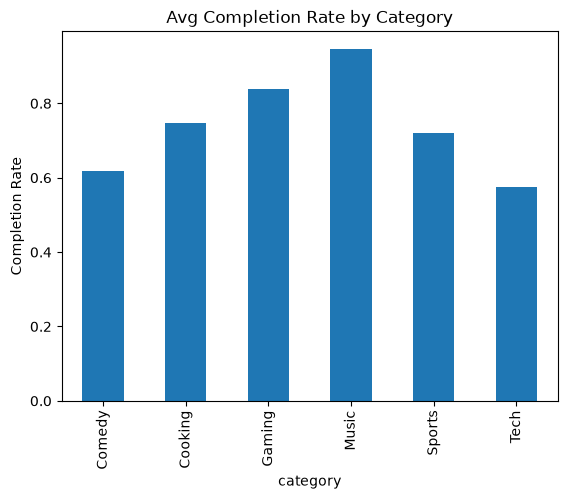

In [13]:
import matplotlib.pyplot as plt

full_df.groupby('category')['completion_rate'].mean().plot(kind='bar', title='Avg Completion Rate by Category')
plt.ylabel('Completion Rate')
plt.show()

In [14]:
videos_df = pd.read_sql_query("SELECT * FROM videos", conn)

# One-hot encode category and language
video_features = pd.get_dummies(videos_df[['video_id', 'category', 'language']], 
                                   columns=['category', 'language'])

# Normalize duration (0-1 scale) and add it as a feature
video_features['duration_norm'] = (videos_df['duration_sec'] - videos_df['duration_sec'].min()) / \
                                    (videos_df['duration_sec'].max() - videos_df['duration_sec'].min())

video_features = video_features.set_index('video_id')
print(video_features)

          category_Comedy  category_Cooking  category_Gaming  category_Music  \
video_id                                                                       
1                    True             False            False           False   
2                    True             False            False           False   
3                   False             False            False           False   
4                   False             False            False           False   
5                   False              True            False           False   
6                   False              True            False           False   
7                   False             False            False           False   
8                   False             False            False           False   
9                   False             False            False            True   
10                  False             False            False            True   
11                  False             Fa

In [15]:
def build_user_profile(user_id, full_df, video_features):
    user_interactions = full_df[full_df['user_id'] == user_id]
    
    # Weight = completion_rate, and boost if explicitly liked
    weights = user_interactions['completion_rate'] + (user_interactions['liked'] * 0.5)
    
    # Get the video feature vectors for videos this user watched
    watched_video_ids = user_interactions['video_id'].values
    watched_features = video_features.loc[watched_video_ids]
    
    # Weighted average
    weighted_profile = (watched_features.T * weights.values).T.sum() / weights.sum()
    
    return weighted_profile

# Build profiles for all 5 users
user_profiles = {}
for uid in range(1, 6):
    user_profiles[uid] = build_user_profile(uid, full_df, video_features)

user_profiles_df = pd.DataFrame(user_profiles).T
print(user_profiles_df)

  category_Comedy category_Cooking category_Gaming category_Music  \
1        0.657787              0.0         0.30123            0.0   
2             0.0         0.369025         0.08413       0.271511   
3        0.108607              0.0             0.0       0.297131   
4        0.234076         0.063694        0.468153       0.234076   
5             0.0         0.568359             0.0            0.0   

  category_Sports category_Tech language_English language_Hindi  \
1             0.0      0.040984         0.918033            0.0   
2        0.275335           0.0         0.095602       0.904398   
3        0.297131      0.297131         0.067623            0.0   
4             0.0           0.0         0.703822       0.296178   
5        0.431641           0.0         0.363281       0.558594   

  language_Spanish duration_norm  
1         0.081967      0.328663  
2              0.0      0.232081  
3         0.932377      0.201134  
4              0.0      0.480633  
5      

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

# Make sure columns align between user_profiles_df and video_features
user_profiles_df = user_profiles_df[video_features.columns]

similarity_matrix = cosine_similarity(user_profiles_df, video_features)

similarity_df = pd.DataFrame(similarity_matrix, 
                               index=user_profiles_df.index, 
                               columns=video_features.index)
print(similarity_df.round(3))

video_id     1      2      3      4      5      6      7      8      9   \
1         0.915  0.920  0.556  0.015  0.571  0.036  0.613  0.122  0.102   
2         0.062  0.066  0.261  0.781  0.335  0.852  0.126  0.042  0.217   
3         0.114  0.118  0.253  0.203  0.074  0.024  0.282  0.817  0.818   
4         0.619  0.628  0.505  0.221  0.576  0.295  0.581  0.087  0.244   
5         0.259  0.262  0.579  0.713  0.682  0.817  0.297  0.086  0.088   

video_id     10     11     12     13     14     15  
1         0.571  0.734  0.279  0.431  0.066  0.051  
2         0.272  0.219  0.672  0.001  0.194  0.794  
3         0.264  0.142  0.085  0.676  0.808  0.224  
4         0.686  0.891  0.654  0.157  0.031  0.428  
5         0.283  0.306  0.429  0.057  0.374  0.422  


In [17]:
def get_recommendations(user_id, similarity_df, full_df, n=3):
    # Exclude videos the user already watched
    watched = full_df[full_df['user_id'] == user_id]['video_id'].tolist()
    
    user_scores = similarity_df.loc[user_id].drop(watched, errors='ignore')
    top_n = user_scores.sort_values(ascending=False).head(n)
    
    return top_n

for uid in range(1, 6):
    print(f"\nTop 3 recommendations for User {uid}:")
    print(get_recommendations(uid, similarity_df, full_df, n=3))


Top 3 recommendations for User 1:
video_id
5     0.571162
10    0.571162
3     0.556381
Name: 1, dtype: float64

Top 3 recommendations for User 2:
video_id
10    0.272453
3     0.261383
11    0.219461
Name: 2, dtype: float64

Top 3 recommendations for User 3:
video_id
7     0.281717
10    0.264155
3     0.252794
Name: 3, dtype: float64

Top 3 recommendations for User 4:
video_id
1    0.619266
7    0.580646
5    0.575510
Name: 4, dtype: float64

Top 3 recommendations for User 5:
video_id
12    0.428985
15    0.421586
11    0.306298
Name: 5, dtype: float64


In [18]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

category_cols = [c for c in video_features.columns if c.startswith('category_')]
language_cols = [c for c in video_features.columns if c.startswith('language_')]
duration_col = ['duration_norm']

def weighted_similarity(user_profiles_df, video_features, 
                          w_category=0.6, w_language=0.3, w_duration=0.1):
    cat_sim = cosine_similarity(user_profiles_df[category_cols], video_features[category_cols])
    lang_sim = cosine_similarity(user_profiles_df[language_cols], video_features[language_cols])
    dur_sim = 1 - np.abs(user_profiles_df[duration_col].values - video_features[duration_col].values.T)
    
    combined = (w_category * cat_sim) + (w_language * lang_sim) + (w_duration * dur_sim)
    return pd.DataFrame(combined, index=user_profiles_df.index, columns=video_features.index)

similarity_df = weighted_similarity(user_profiles_df, video_features)
print(similarity_df.round(3))

video_id        1         2         3         4         5         6   \
1         0.910591  0.913294  0.379459  0.075242  0.390269  0.086053   
2         0.108329  0.111031   0.42715  0.688546  0.539618  0.803246   
3         0.225478  0.228181  0.454046   0.42694   0.11749  0.098806   
4         0.571902  0.574605  0.341964  0.176406   0.41902  0.253462   
5         0.246089  0.248791  0.622486  0.704416  0.732302  0.825044   

video_id        7         8         9         10        11        12  \
1         0.419666  0.155676  0.123543  0.390269  0.581095  0.309311   
2         0.108799   0.09528  0.394546  0.431488  0.148033  0.441861   
3         0.434814  0.730345  0.728543  0.456435  0.041815   0.04714   
4         0.374397  0.079865  0.325118  0.596227   0.81148  0.678354   
5         0.232857  0.123364  0.121562  0.254478  0.178803  0.293166   

video_id        13        14        15  
1          0.63936  0.103723  0.094161  
2         0.077693   0.39201  0.695586  
3         0

In [19]:
for uid in range(1, 6):
    print(f"\nTop 3 recommendations for User {uid}:")
    print(get_recommendations(uid, similarity_df, full_df, n=3))


Top 3 recommendations for User 1:
video_id
5     0.390269
10    0.390269
3     0.379459
Name: 1, dtype: object

Top 3 recommendations for User 2:
video_id
10    0.431488
3      0.42715
9     0.394546
Name: 2, dtype: object

Top 3 recommendations for User 3:
video_id
10    0.456435
3     0.454046
7     0.434814
Name: 3, dtype: object

Top 3 recommendations for User 4:
video_id
1     0.571902
15    0.438776
5      0.41902
Name: 4, dtype: object

Top 3 recommendations for User 5:
video_id
15    0.339112
12    0.293166
10    0.254478
Name: 5, dtype: object


In [20]:
similarity_df = weighted_similarity(user_profiles_df, video_features,
                                      w_category=0.75, w_language=0.15, w_duration=0.10)

for uid in range(1, 6):
    print(f"\nTop 3 recommendations for User {uid}:")
    print(get_recommendations(uid, similarity_df, full_df, n=3))


Top 3 recommendations for User 1:
video_id
12    0.371665
5     0.240864
10    0.240864
Name: 1, dtype: object

Top 3 recommendations for User 2:
video_id
10    0.490987
3     0.487709
9     0.469813
Name: 2, dtype: object

Top 3 recommendations for User 3:
video_id
10    0.530321
3     0.527932
15    0.516768
Name: 3, dtype: object

Top 3 recommendations for User 4:
video_id
1     0.494508
15    0.441459
9     0.385981
Name: 4, dtype: object

Top 3 recommendations for User 5:
video_id
15    0.214221
10    0.173255
12    0.168275
Name: 5, dtype: object


In [21]:
def contextual_boost(user_id, video_id, current_hour, users_df, videos_df):
    boost = 1.0
    
    user_row = users_df[users_df['user_id'] == user_id].iloc[0]
    video_row = videos_df[videos_df['video_id'] == video_id].iloc[0]
    
    # Location-based boost: same-location users tend to engage more with trending local content
    # (placeholder logic — you can refine with real trending data later)
    
    # Time-of-day boost: example — gaming/comedy do better at night, cooking/tech during day
    night_categories = ['Gaming', 'Comedy', 'Music']
    day_categories = ['Cooking', 'Tech', 'Sports']
    
    is_night = current_hour >= 19 or current_hour <= 5
    
    if is_night and video_row['category'] in night_categories:
        boost *= 1.15
    elif not is_night and video_row['category'] in day_categories:
        boost *= 1.15
    
    return boost

def get_recommendations_with_context(user_id, similarity_df, full_df, videos_df, users_df, 
                                       current_hour, n=3):
    watched = full_df[full_df['user_id'] == user_id]['video_id'].tolist()
    user_scores = similarity_df.loc[user_id].drop(watched, errors='ignore').copy()
    
    boosted_scores = user_scores.copy()
    for vid in boosted_scores.index:
        boosted_scores[vid] *= contextual_boost(user_id, vid, current_hour, users_df, videos_df)
    
    return boosted_scores.sort_values(ascending=False).head(n)

# Example: User 1 requesting at 10pm (night) vs 2pm (day)
print("User 1 at 10 PM:")
print(get_recommendations_with_context(1, similarity_df, full_df, videos_df, users_df, current_hour=22, n=3))

print("\nUser 1 at 2 PM:")
print(get_recommendations_with_context(1, similarity_df, full_df, videos_df, users_df, current_hour=14, n=3))

User 1 at 10 PM:
video_id
12    0.427415
10    0.276993
5     0.240864
Name: 1, dtype: object

User 1 at 2 PM:
video_id
12    0.371665
5     0.276993
3     0.264561
Name: 1, dtype: object


In [24]:
def get_cold_start_recommendations(user_id, users_df, videos_df, full_df, n=3):
    user_row = users_df[users_df['user_id'] == user_id].iloc[0]
    user_language = user_row['language']
    
    # Popularity = how many likes each video has gotten across all users
    video_popularity = full_df.groupby('video_id')['liked'].sum()
    
    # Prefer videos matching the new user's language
    candidates = videos_df.copy()
    candidates['popularity'] = candidates['video_id'].map(video_popularity).fillna(0)
    candidates['language_match'] = candidates['language'] == user_language
    
    # Sort: language match first, then popularity
    candidates = candidates.sort_values(['language_match', 'popularity'], ascending=[False, False])
    
    return candidates[['video_id', 'category', 'language', 'popularity']].head(n)

# Simulate a brand new user (user_id 6, Hindi speaker, no interactions yet)
new_user = pd.DataFrame([{'user_id': 6, 'age': 24, 'language': 'Hindi', 'location': 'Mumbai'}])
print(get_cold_start_recommendations(6, new_user, videos_df, full_df, n=3))

    video_id category language  popularity
3          4   Sports    Hindi           2
5          6  Cooking    Hindi           2
11        12   Gaming    Hindi           1


In [23]:
def get_final_recommendations(user_id, users_df, videos_df, full_df, similarity_df, current_hour, n=3):
    if user_id not in full_df['user_id'].unique():
        return get_cold_start_recommendations(user_id, users_df, videos_df, full_df, n)
    else:
        return get_recommendations_with_context(user_id, similarity_df, full_df, videos_df, users_df, current_hour, n)

In [25]:
def leave_one_out_eval(user_id, full_df, video_features, k=3):
    user_data = full_df[full_df['user_id'] == user_id].sort_values('timestamp')
    liked_data = user_data[user_data['liked'] == 1]
    
    if len(liked_data) < 2:
        return None  # not enough data to hold one out
    
    # Hold out the most recent liked video
    held_out = liked_data.iloc[-1]
    held_out_video = held_out['video_id']
    
    # Build profile WITHOUT the held-out interaction
    train_data = full_df[~((full_df['user_id'] == user_id) & (full_df['video_id'] == held_out_video))]
    
    weights = train_data[train_data['user_id'] == user_id]['completion_rate'] + \
              (train_data[train_data['user_id'] == user_id]['liked'] * 0.5)
    watched_ids = train_data[train_data['user_id'] == user_id]['video_id'].values
    watched_features = video_features.loc[watched_ids]
    
    profile = (watched_features.T * weights.values).T.sum() / weights.sum()
    profile_df = pd.DataFrame([profile])[video_features.columns]
    
    # Score against ALL videos the user hasn't watched (except the held-out one, which should be included)
    watched_excl_heldout = train_data[train_data['user_id'] == user_id]['video_id'].tolist()
    candidates = video_features.drop(watched_excl_heldout, errors='ignore')
    
    sim = weighted_similarity(profile_df, candidates, w_category=0.75, w_language=0.15, w_duration=0.10)
    ranked = sim.iloc[0].sort_values(ascending=False)
    
    rank_position = list(ranked.index).index(held_out_video) + 1 if held_out_video in ranked.index else None
    hit = rank_position is not None and rank_position <= k
    
    return {'user_id': user_id, 'held_out_video': held_out_video, 
            'rank': rank_position, 'hit@k': hit}

results = []
for uid in range(1, 6):
    r = leave_one_out_eval(uid, full_df, video_features, k=3)
    if r:
        results.append(r)

results_df = pd.DataFrame(results)
print(results_df)

precision_at_k = results_df['hit@k'].mean()
print(f"\nPrecision@3 (Hit Rate): {precision_at_k:.2%}")

   user_id  held_out_video  rank  hit@k
0        1              11     4  False
1        2               4     3   True
2        3               9     5  False
3        4               2     6  False
4        5               5     1   True

Precision@3 (Hit Rate): 40.00%


In [26]:
# Baseline comparison: how often would popularity-based recommendation alone hit the held-out video?
def popularity_baseline_eval(user_id, full_df, videos_df, k=3):
    user_data = full_df[full_df['user_id'] == user_id].sort_values('timestamp')
    liked_data = user_data[user_data['liked'] == 1]
    if len(liked_data) < 2:
        return None
    held_out_video = liked_data.iloc[-1]['video_id']
    
    watched = user_data['video_id'].tolist()
    watched.remove(held_out_video)
    
    popularity = full_df[full_df['video_id'] != held_out_video].groupby('video_id')['liked'].sum()
    candidates = popularity.drop(watched, errors='ignore').sort_values(ascending=False)
    
    rank = list(candidates.index).index(held_out_video) + 1 if held_out_video in candidates.index else None
    return rank is not None and rank <= k

baseline_hits = [popularity_baseline_eval(uid, full_df, videos_df, k=3) for uid in range(1, 6)]
baseline_precision = sum(h for h in baseline_hits if h) / len(baseline_hits)
print(f"Popularity baseline Precision@3: {baseline_precision:.2%}")
print(f"Content-based model Precision@3: {precision_at_k:.2%}")

Popularity baseline Precision@3: 0.00%
Content-based model Precision@3: 40.00%
